# Average Volatility Dimensioning (AVD) — a gentle, worked example

This notebook explains the AVD equations from [AVD_function.py](AVD_function.py) using a **very small simulated multivariate time series** so every number can be traced by hand.

The core question AVD answers is:

> Within a short sliding window, **do all sensor dimensions fluctuate by a similar amount, or do some dimensions become much more volatile than others?**

AVD reduces a multivariate signal to a single curve that is **large when dimensions disagree in how much they are moving**, and **close to zero when they all move by about the same amount** (regardless of what the actual amount is).

## 1. The equations

Let the multivariate time series be $X \in \mathbb{R}^{T \times D}$ with $T$ time steps and $D$ feature dimensions. Let $w$ be the window size and $s$ the window increment.

### Step 1 — Per-dimension volatility inside a window

For a window starting at time $t$ and dimension $d$, let $X_{t:t+w,\,d}$ be the $w$ values of that dimension inside the window, and $\bar{X}_{t,d}$ their mean.

**MAD (Mean Absolute Deviation):**
$$
v_{t,d} \;=\; \frac{1}{w} \sum_{i=0}^{w-1} \left| X_{t+i,\,d} - \bar{X}_{t,d} \right|
$$

**SD (Standard Deviation, sample, ddof=1):**
$$
v_{t,d} \;=\; \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} \left( X_{t+i,\,d} - \bar{X}_{t,d} \right)^2 }
$$

After this step, every window produces a vector of $D$ volatility numbers $v_t = (v_{t,1},\dots,v_{t,D})$.

### Step 2 — Pairwise squared differences between dimensions

We build a $D\times D$ matrix whose entries compare the volatility of every pair of dimensions:
$$
M_{t}[i,j] \;=\; \bigl(v_{t,i} - v_{t,j}\bigr)^2
$$

### Step 3 — Average the upper triangle (excluding the diagonal)

The diagonal is always 0 and the matrix is symmetric, so only the $\binom{D}{2}$ pairs above the diagonal carry information:
$$
\mathrm{AVD}_t \;=\; \frac{1}{\binom{D}{2}} \sum_{i<j} \bigl(v_{t,i} - v_{t,j}\bigr)^2
$$

That single scalar $\mathrm{AVD}_t$ is the AVD value at window position $t$. Sliding the window yields the one-dimensional AVD signal.

## 2. A tiny simulated dataset

We pick the smallest example that is still interesting: **3 dimensions, 20 time steps**. We will use window size $w = 5$ and increment $s = 1$.

The three sensors are designed so the story is easy to see:
- `sensor_A` — calm sine wave, same amplitude the whole time.
- `sensor_B` — also a sine wave, but between time steps 8 and 13 its amplitude **jumps up** (becomes much more volatile).
- `sensor_C` — calm sine wave the whole time.

So we expect the AVD curve to be **small at the start**, **spike around time steps 8-13** (when B's volatility diverges from A and C), and then come back down once B calms again.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from AVD_function import calculate_AVD_feature

np.random.seed(0)

T = 20
t = np.arange(T)

sensor_A = 1.0 * np.sin(0.6 * t)
sensor_C = 1.0 * np.sin(0.6 * t + 0.3)

amplitude_B = np.where((t >= 8) & (t <= 13), 4.0, 1.0)
sensor_B = amplitude_B * np.sin(0.6 * t + 0.1)

df = pd.DataFrame({
    'sensor_A': sensor_A,
    'sensor_B': sensor_B,
    'sensor_C': sensor_C,
})
df

,sensor_A,sensor_B,sensor_C
0,0.000000,0.099833,0.295520
1,0.564642,0.644218,0.783327
2,0.932039,0.963558,0.997495
3,0.973848,0.946300,0.863209
4,0.675463,0.598472,0.427380
5,0.141120,0.041581,-0.157746
6,-0.442520,-0.529836,-0.687766
7,-0.871576,-0.916166,-0.977530
8,-0.996165,-3.929810,-0.925815
9,-0.772764,-2.822161,-0.550686


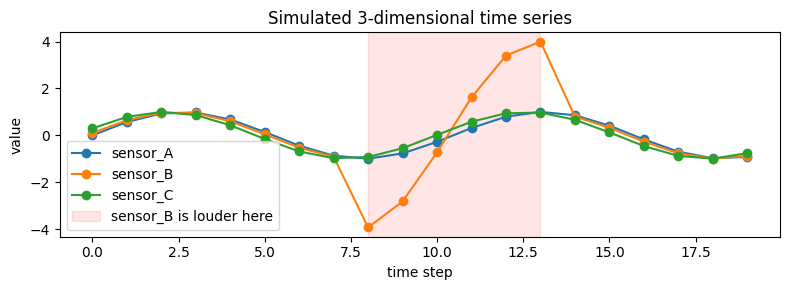

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
for col in df.columns:
    ax.plot(df.index, df[col], marker='o', label=col)
ax.axvspan(8, 13, color='red', alpha=0.1, label='sensor_B is louder here')
ax.set_xlabel('time step')
ax.set_ylabel('value')
ax.set_title('Simulated 3-dimensional time series')
ax.legend()
plt.tight_layout()
plt.show()

## 3. One window, calculated by hand

Let's pick the window that starts at time step $t = 8$ — right where sensor_B's amplitude jumps. With $w = 5$ this window covers rows `8, 9, 10, 11, 12`.

We will compute, for this single window:
1. The per-dimension means $\bar{X}_{t,d}$
2. The per-dimension MAD values $v_{t,d}$
3. The pairwise squared-difference matrix $M_t$
4. The AVD scalar = average of the upper triangle

In [5]:
w = 5
start = 8
window = df.iloc[start:start + w]
window

,sensor_A,sensor_B,sensor_C
8,-0.996165,-3.929810,-0.925815
9,-0.772764,-2.822161,-0.550686
10,-0.279415,-0.728650,0.016814
11,0.311541,1.619400,0.578440
12,0.793668,3.401746,0.938000


In [6]:
means = window.mean()
print('Per-dimension means inside the window:')
print(means)

mad = (window - means).abs().mean()
print('\nPer-dimension MAD (v_{t,d}):')
print(mad)

Per-dimension means inside the window:
sensor_A   -0.188627
sensor_B   -0.491895
sensor_C    0.011351
dtype: float64

Per-dimension MAD (v_{t,d}):
sensor_A    0.592985
sensor_B    2.401975
sensor_C    0.599681
dtype: float64


Notice how `sensor_B`'s MAD is noticeably larger than `sensor_A`'s and `sensor_C`'s — that is the *disagreement* AVD will pick up.

Now the pairwise squared-difference matrix $M_t[i,j] = (v_{t,i} - v_{t,j})^2$:

In [7]:
v = mad.values
M = (v[:, None] - v[None, :]) ** 2
M_df = pd.DataFrame(M, index=mad.index, columns=mad.index)
M_df.round(4)

,sensor_A,sensor_B,sensor_C
sensor_A,0.0000,3.2724,0.0000
sensor_B,3.2724,0.0000,3.2483
sensor_C,0.0000,3.2483,0.0000


In [ ]:
iu = np.triu_indices_from(M, k=1)
upper_vals = M[iu]
print('Upper-triangle pairs (i<j):')
for (i, j), val in zip(zip(*iu), upper_vals):
    print(f'  ({mad.index[i]}, {mad.index[j]}) -> {val:.4f}')

avd_manual = upper_vals.mean()
print(f'\nAVD at window starting t=8 (manual): {avd_manual:.6f}')

Upper-triangle pairs (i<j):
  (sensor_A, sensor_B) -> 3.2724
  (sensor_A, sensor_C) -> 0.0000
  (sensor_B, sensor_C) -> 3.2483

AVD at window starting t=8 (manual): 2.173583


## 4. Reproduce with the repository function

The function `calculate_AVD_feature` in [AVD_function.py](AVD_function.py) does exactly the above for every sliding window. Its output index `Time Point` corresponds to the **last** row included in each window (i.e. `start + w - 1`). So the window that starts at `t = 8` will show up at `Time Point = 12`.

In [9]:
avd_mad = calculate_AVD_feature(df, metric='MAD', w_size=5, w_incre=1)
avd_mad

,MAD
Time Point,
4,6.563639e-04
5,7.985221e-03
6,3.549965e-03
7,4.986888e-07
8,3.035363e-01
9,8.099203e-01
10,6.736365e-01
11,8.621818e-01
12,2.173583e+00


In [10]:
from_function = avd_mad.loc[12, 'MAD']
print(f'From function, Time Point = 12 (window started at t=8): {from_function:.6f}')
print(f'Manual calculation for the same window:                 {avd_manual:.6f}')
assert np.isclose(from_function, avd_manual), 'Manual and function values should match.'
print('\nOK - manual AVD and library AVD agree.')

From function, Time Point = 12 (window started at t=8): 2.173583
Manual calculation for the same window:                 2.173583

OK - manual AVD and library AVD agree.


## 5. The full AVD signal next to the raw data

We can now overlay the AVD curve on the raw sensors. Expect a clear bump where `sensor_B` diverges.

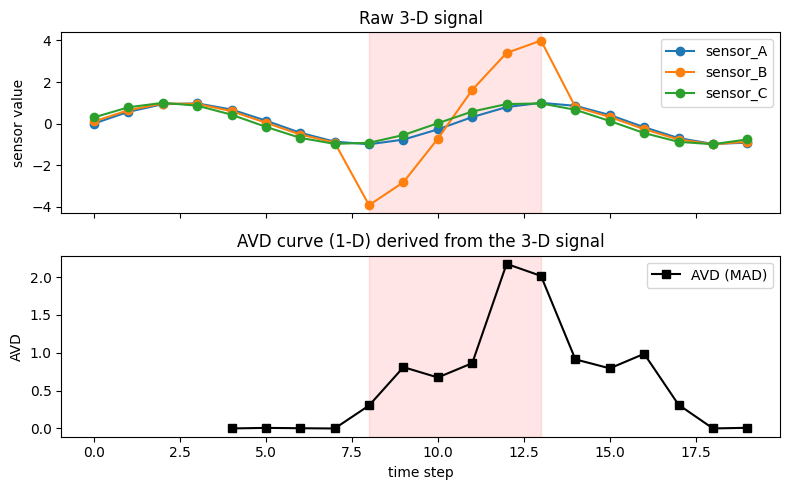

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

for col in df.columns:
    ax1.plot(df.index, df[col], marker='o', label=col)
ax1.axvspan(8, 13, color='red', alpha=0.1)
ax1.set_ylabel('sensor value')
ax1.set_title('Raw 3-D signal')
ax1.legend(loc='upper right')

ax2.plot(avd_mad.index, avd_mad['MAD'], marker='s', color='black', label='AVD (MAD)')
ax2.axvspan(8, 13, color='red', alpha=0.1)
ax2.set_xlabel('time step')
ax2.set_ylabel('AVD')
ax2.set_title('AVD curve (1-D) derived from the 3-D signal')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. MAD vs. SD — same idea, different volatility measure

Swapping the `metric` argument replaces the per-dimension MAD with the per-dimension standard deviation. The shape of the curve is similar, but the scale differs (SD is generally larger than MAD for the same data, so the squared differences are larger too).

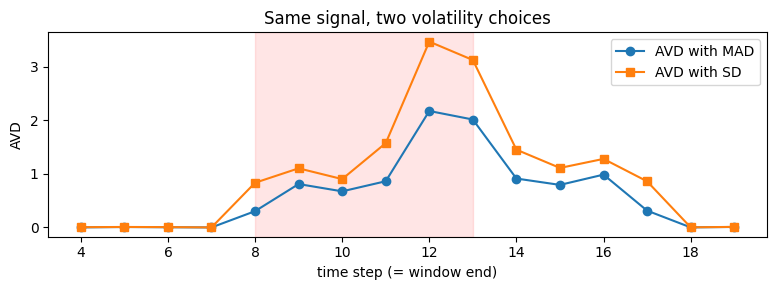

In [12]:
avd_sd = calculate_AVD_feature(df, metric='SD', w_size=5, w_incre=1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(avd_mad.index, avd_mad['MAD'], marker='o', label='AVD with MAD')
ax.plot(avd_sd.index, avd_sd['SD'], marker='s', label='AVD with SD')
ax.axvspan(8, 13, color='red', alpha=0.1)
ax.set_xlabel('time step (= window end)')
ax.set_ylabel('AVD')
ax.set_title('Same signal, two volatility choices')
ax.legend()
plt.tight_layout()
plt.show()

## 7. What AVD is *not* sensitive to — a sanity check

A very important property to internalize: **AVD measures *disagreement* between dimensions, not the level of volatility itself.**

If all three sensors become very noisy at the same time by the same amount, their per-dimension volatilities go up together, their pairwise differences stay small, and **AVD stays close to zero**. Only dimension-level *heterogeneity* in volatility moves AVD.

Below we build a second cycle in which all three sensors become loud together, and compare it to our original cycle (where only `sensor_B` became loud).

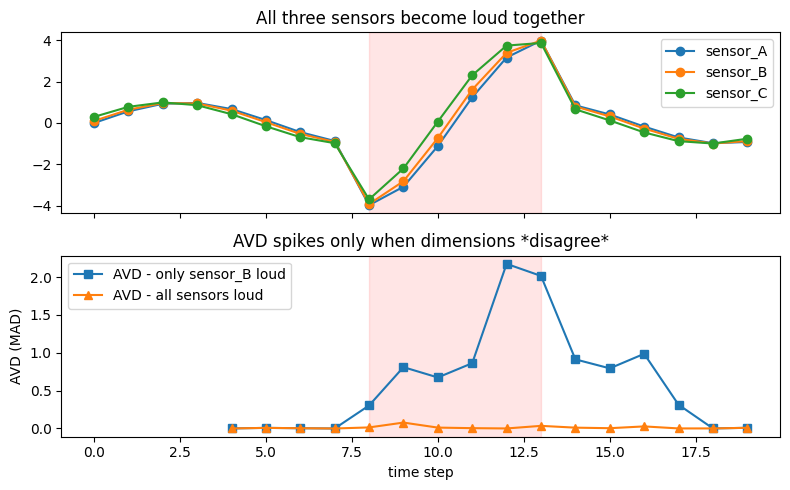

In [13]:
amp_all = np.where((t >= 8) & (t <= 13), 4.0, 1.0)
df_all_loud = pd.DataFrame({
    'sensor_A': amp_all * np.sin(0.6 * t),
    'sensor_B': amp_all * np.sin(0.6 * t + 0.1),
    'sensor_C': amp_all * np.sin(0.6 * t + 0.3),
})

avd_all_loud = calculate_AVD_feature(df_all_loud, metric='MAD', w_size=5, w_incre=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for col in df_all_loud.columns:
    ax1.plot(df_all_loud.index, df_all_loud[col], marker='o', label=col)
ax1.axvspan(8, 13, color='red', alpha=0.1)
ax1.set_title('All three sensors become loud together')
ax1.legend(loc='upper right')

ax2.plot(avd_mad.index, avd_mad['MAD'], marker='s', label='AVD - only sensor_B loud')
ax2.plot(avd_all_loud.index, avd_all_loud['MAD'], marker='^', label='AVD - all sensors loud')
ax2.axvspan(8, 13, color='red', alpha=0.1)
ax2.set_xlabel('time step')
ax2.set_ylabel('AVD (MAD)')
ax2.set_title('AVD spikes only when dimensions *disagree*')
ax2.legend()
plt.tight_layout()
plt.show()

## 8. How the parameters change the output

- **`w_size` (window length).** Smaller windows react faster to local changes in volatility, but the per-dimension MAD/SD is noisier because it is based on fewer points. Larger windows are smoother but blur short events. Pick a window that is long enough for the volatility estimate to be stable but short enough to resolve the pattern you care about.
- **`w_incre` (window stride).** Controls how densely the AVD curve is sampled. `w_incre=1` gives one AVD value per time step; larger strides subsample and speed up computation at the cost of temporal resolution.
- **`metric`.** `'MAD'` is a robust, L1-style spread; `'SD'` is the familiar L2-style spread and is more sensitive to outliers. The AVD *shape* is usually similar; the *scale* differs.
- **Number of dimensions $D$.** The denominator of AVD is $\binom{D}{2}$, so the AVD scale is normalized by the number of pairs. Adding a dimension that behaves like the existing ones tends to pull AVD down (more pairs that agree); adding a dimension that behaves very differently can push it up.

## 9. Summary

For each sliding window $t$ of a multivariate series:

1. Compute a per-dimension volatility $v_{t,d}$ (MAD or SD).
2. Square every pairwise difference $(v_{t,i} - v_{t,j})^2$.
3. Average the $\binom{D}{2}$ upper-triangle entries.

The result is a one-dimensional signal that is **high when the dimensions' volatilities disagree** and **low when they move in lockstep**, independent of the absolute level of noise.